# Part 3 — Extensions: warm dark matter & halo concentrations

In [Part 2](02-analysis.ipynb) you measured Σ<sub>sub</sub> for a CDM model. This
notebook explores two variations, each defined by its own parameter file you can
run exactly like the fiducial one:

- **Warm dark matter (WDM)** — `parameters/subhalos_1e13_z0.5_WDM.xml`. A 3 keV
  thermal relic. This is the headline dark-matter-probe application:
  Σ<sub>sub</sub> is exactly the quantity strong-lensing studies use to constrain
  WDM, because a warmer particle suppresses low-mass subhalos.
- **A different halo concentration model** —
  `parameters/subhalos_1e13_z0.5_ludlow.xml`. Swaps the fiducial scale-radius
  model for the analytic Ludlow et al. (2016) relation, to test how sensitive
  Σ<sub>sub</sub> is to the concentration prescription.

To generate the outputs yourself:

```bash
galacticus run tutorial/parameters/subhalos_1e13_z0.5_WDM.xml
galacticus run tutorial/parameters/subhalos_1e13_z0.5_ludlow.xml
```

As in Part 2, this notebook falls back to precomputed copies in `tutorial/data/`
if you haven't run them.

## Setup — a small helper to load any of our models

We reuse the same recipe from Part 2 (infall mass, projected positions,
Σ<sub>sub</sub>) wrapped in a couple of functions so we can apply it to each
model.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from dendros import open_outputs

def find_output(basename):
    """Locate a *complete* model output: your own run first, then the shipped fallback.
    Skips files that exist but don't contain evolved subhalo data (e.g. an
    interrupted run), so we always fall through to a usable file."""
    key = "Outputs/Output1/nodeData/nodeIsIsolated"
    for p in [basename, f"../{basename}",
              f"tutorial/data/{basename}", f"../tutorial/data/{basename}",
              f"data/{basename}"]:
        if not Path(p).exists():
            continue
        try:
            with h5py.File(p, "r") as f:
                if key in f:
                    return p
        except OSError:
            pass
    raise FileNotFoundError(f"No complete {basename} found. Run the parameter file, or check tutorial/data/.")

def load_model(basename):
    """Return a dict of the subhalo arrays we need, in tidy units."""
    with open_outputs(find_output(basename)) as c:
        d = c.read("Output1", [
            "nodeData/nodeIsIsolated", "nodeData/basicMass",
            "nodeData/positionOrbitalX", "nodeData/positionOrbitalY",
            "nodeData/darkMatterOnlyRadiusVirial", "nodeData/darkMatterProfileScale",
            "nodeData/mergerTreeIndex",
        ])
    iso   = d["nodeData/nodeIsIsolated"].astype(int)
    r_vir = d["nodeData/darkMatterOnlyRadiusVirial"].to("kpc").value
    r_s   = d["nodeData/darkMatterProfileScale"].to("kpc").value
    return dict(
        is_sub  = iso == 0,
        is_host = iso == 1,
        m       = d["nodeData/basicMass"].to("Msun").value,                 # infall mass
        R_proj  = np.hypot(d["nodeData/positionOrbitalX"].to("kpc").value,
                           d["nodeData/positionOrbitalY"].to("kpc").value),  # projected radius
        conc    = r_vir / r_s,                                               # concentration
        tree    = d["nodeData/mergerTreeIndex"].astype(int),
        Rvir    = float(np.median(r_vir[iso == 1])),
        n_trees = int((iso == 1).sum()),
    )

M0 = 1.0e8
M_LO, M_HI = 10**7.75, 10**8.25          # half-decade bin around 10^8 Msun

def sigma_sub(g, aperture_frac=1.0):
    """Sigma_sub (mean, std over hosts) within aperture_frac * R_vir, using infall mass."""
    R_ap = aperture_frac * g["Rvir"]
    area = np.pi * R_ap**2
    in_bin = g["is_sub"] & (g["m"] >= M_LO) & (g["m"] < M_HI) & (g["R_proj"] < R_ap)
    per = np.array([M0 * np.count_nonzero(in_bin & (g["tree"] == t)) / ((M_HI - M_LO) * area)
                    for t in np.unique(g["tree"][g["is_host"]])])
    return per.mean(), per.std()

def mass_function(g):
    """Projected infall-mass function within R_vir: bin centres and dN/dm/dA."""
    edges = np.logspace(np.log10(3e7), 10, 16)
    centre, width = np.sqrt(edges[:-1]*edges[1:]), np.diff(edges)
    sel = g["is_sub"] & (g["R_proj"] < g["Rvir"])
    counts, _ = np.histogram(g["m"][sel], bins=edges)
    dN = counts / (g["n_trees"] * width * np.pi * g["Rvir"]**2)
    return centre, dN, counts

cdm = load_model("subhalos_1e13_z0.5.hdf5")
print(f"CDM loaded: {cdm['is_sub'].sum()} subhalos, {cdm['n_trees']} hosts")

CDM loaded: 38648 subhalos, 8 hosts


## A. Cold vs. warm dark matter

Load the WDM model and compare its projected subhalo mass function to CDM. The
WDM parameter file uses a 3 keV thermal relic via the Bode et al. (2001)
transfer function and the Barkana et al. (2001) collapse barrier — see the file
header for details.

WDM loaded: 12504 subhalos (vs 38648 for CDM)


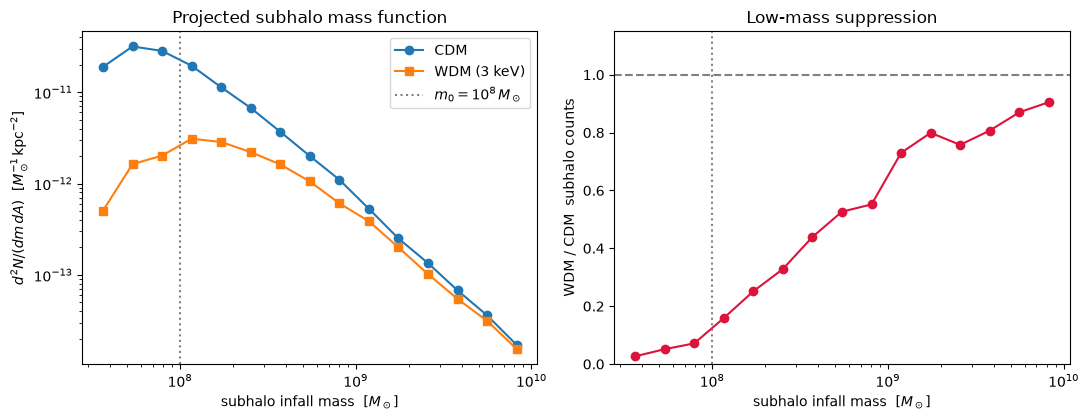

Sigma_sub within R_vir                : CDM 0.0021   WDM 0.0003 kpc^-2   (WDM/CDM = 0.13)
Sigma_sub within 0.1 R_vir (central)  : CDM 0.0049   WDM 0.0006 kpc^-2   (WDM/CDM = 0.12)


In [2]:
wdm = load_model("subhalos_1e13_z0.5_WDM.hdf5")
print(f"WDM loaded: {wdm['is_sub'].sum()} subhalos (vs {cdm['is_sub'].sum()} for CDM)")

c_cdm, dN_cdm, n_cdm = mass_function(cdm)
c_wdm, dN_wdm, n_wdm = mass_function(wdm)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))

# Left: the two mass functions
ok = n_cdm > 5
ax1.loglog(c_cdm[ok], dN_cdm[ok], "o-", label="CDM")
ok = n_wdm > 5
ax1.loglog(c_wdm[ok], dN_wdm[ok], "s-", label="WDM (3 keV)")
ax1.axvline(M0, color="grey", ls=":", label=r"$m_0 = 10^8\,M_\odot$")
ax1.set_xlabel(r"subhalo infall mass  [$M_\odot$]")
ax1.set_ylabel(r"$d^2N/(dm\,dA)$  [$M_\odot^{-1}\,\mathrm{kpc}^{-2}$]")
ax1.set_title("Projected subhalo mass function")
ax1.legend()

# Right: the suppression ratio WDM/CDM
ok = (n_cdm > 5) & (n_wdm >= 0)
ratio = np.divide(dN_wdm, dN_cdm, out=np.full_like(dN_cdm, np.nan), where=dN_cdm > 0)
ax2.semilogx(c_cdm[ok], ratio[ok], "o-", color="crimson")
ax2.axhline(1.0, color="grey", ls="--")
ax2.axvline(M0, color="grey", ls=":")
ax2.set_ylim(0, 1.15)
ax2.set_xlabel(r"subhalo infall mass  [$M_\odot$]")
ax2.set_ylabel("WDM / CDM  subhalo counts")
ax2.set_title("Low-mass suppression")
plt.tight_layout()
plt.show()

for label, frac in [("within R_vir", 1.0), ("within 0.1 R_vir (central)", 0.1)]:
    s_c = sigma_sub(cdm, frac)[0]
    s_w = sigma_sub(wdm, frac)[0]
    print(f"Sigma_sub {label:28}: CDM {s_c:.4f}   WDM {s_w:.4f} kpc^-2   (WDM/CDM = {s_w/s_c:.2f})")

**This is the dark-matter probe in action.** The warm model produces far
fewer subhalos below its free-streaming ("half-mode") mass — the suppression
ratio drops steeply below ~10<sup>9</sup> M<sub>☉</sub> and, at the
10<sup>8</sup> M<sub>☉</sub> pivot, Σ<sub>sub</sub> falls by roughly an order of
magnitude, while the two models converge at high mass. Strong-lensing analyses
turn exactly this effect around: an observed Σ<sub>sub</sub> places a **lower
limit on the dark-matter particle mass** (an upper limit on how warm it can be).

Try re-running the WDM parameter file with a warmer particle (lower `mass`, e.g.
2 keV) and watch the suppression deepen and move to higher masses.

## B. How much does the halo concentration matter?

Halo concentration controls how tightly bound subhalos are, and therefore how
well they survive tidal stripping — so in principle it feeds through to
Σ<sub>sub</sub>. Let's give it a real push: `subhalos_1e13_z0.5_ludlow.xml` uses
the analytic Ludlow et al. (2016) scale-radius model with its concentration
normalisation `C` lowered from the ~650 default to **300**, which makes halos
noticeably *less* concentrated. Does that move Σ<sub>sub</sub>?

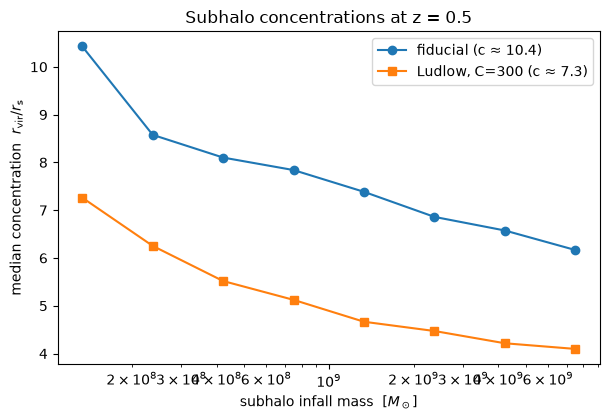

model                        Sigma_sub(R_vir) Sigma_sub(0.1 R_vir)
fiducial (c ≈ 10.4)                    0.0021               0.0049
Ludlow C=300 (c ≈ 7.3)                 0.0020               0.0047


In [3]:
ludlow = load_model("subhalos_1e13_z0.5_ludlow.hdf5")

# Median subhalo concentration vs infall mass, for both models
edges = np.logspace(8, 10, 9)
centre = np.sqrt(edges[:-1]*edges[1:])
def median_conc(g):
    sel = g["is_sub"] & (g["R_proj"] < g["Rvir"])
    out = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = sel & (g["m"] >= lo) & (g["m"] < hi)
        out.append(np.median(g["conc"][m]) if m.sum() > 20 else np.nan)
    return np.array(out)

fig, ax = plt.subplots(figsize=(6.2, 4.3))
ax.semilogx(centre, median_conc(cdm), "o-", label="fiducial (c ≈ 10.4)")
ax.semilogx(centre, median_conc(ludlow), "s-", label="Ludlow, C=300 (c ≈ 7.3)")
ax.set_xlabel(r"subhalo infall mass  [$M_\odot$]")
ax.set_ylabel(r"median concentration  $r_\mathrm{vir}/r_\mathrm{s}$")
ax.set_title("Subhalo concentrations at z = 0.5")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'model':28} {'Sigma_sub(R_vir)':>16} {'Sigma_sub(0.1 R_vir)':>20}")
for name, g in [("fiducial (c ≈ 10.4)", cdm), ("Ludlow C=300 (c ≈ 7.3)", ludlow)]:
    print(f"{name:28} {sigma_sub(g,1.0)[0]:16.4f} {sigma_sub(g,0.1)[0]:20.4f}")

Even though we made the halos **substantially less concentrated** (median
concentration near 10<sup>8</sup> M<sub>☉</sub> drops from ~10.4 to ~7.3), the two
Σ<sub>sub</sub> values above **agree to a few percent**. So the surviving subhalo
abundance near 10<sup>8</sup> M<sub>☉</sub> is remarkably *robust* to
concentration — in sharp contrast to the dark-matter particle in §A, which
changed it by an order of magnitude. That's worth knowing when interpreting a
Σ<sub>sub</sub> measurement: not every modelling choice matters equally, and
changing one thing at a time like this is how you find out which ones do.

**Why so robust? It's the resolution again.** A subhalo is only counted if its
bound mass stays above our 3 × 10<sup>7</sup> M<sub>☉</sub> floor, so the
survivors are — almost by definition — the ones that have suffered *little*
tidal stripping. Concentration mostly controls *how much* a subhalo is stripped,
but the subhalos we keep have barely been stripped at all, so their concentration
has little to act on. At higher resolution we would also retain heavily-stripped
subhalos, whose survive-or-not fate *does* depend on concentration — so we would
expect concentration to matter more there. This robustness is thus partly
physical and partly an artefact of running coarse for speed (the same resolution
limit that makes Σ<sub>sub</sub> an underestimate in Part 2).

**Ideas to keep exploring**

- Vary the WDM `mass` (2–10 keV) and map out Σ<sub>sub</sub> vs. particle mass —
  this *is* the constraint curve.
- Change the host `massTree` or the base redshift and see how Σ<sub>sub</sub>
  responds.
- Compare current *bound* mass vs *infall* mass (as in Part 2) for the WDM run.